In [2]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_single_atom
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFE_seq
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, display_table, display_table_compare
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg
import matplotlib.pyplot as plt

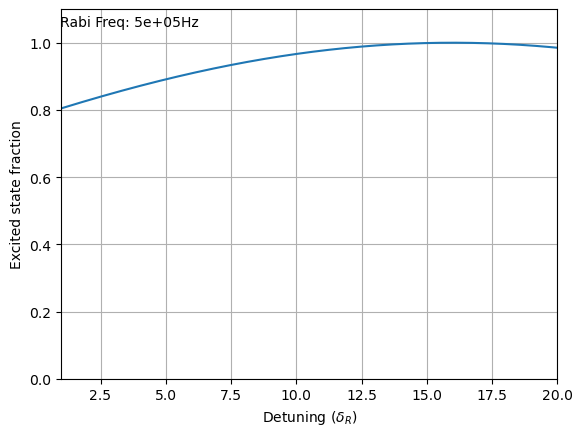

0.8047675549184174


In [15]:
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq

time_steps = 1
detunings = np.linspace(dR,20*dR,500)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[8] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

prob_arr = np.zeros(len(detunings))

for i, det in enumerate(detunings):
    pulse1 = UpPulse(laser_det=np.full(time_steps, det), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    seq = PulseSequence()
    seq.add_pulses(pulse1)

    wave_func, times = simulate_pulses_single_atom(pulse_seq= seq, basis= basis, initial_state= initial_state, d_shift= 15*dR)

    prob = np.abs(wave_func[-1][9])**2
    prob_arr[i] = prob


plt.plot(detunings/dR, prob_arr)
plt.ylim(0,1.1)
plt.xlim(detunings[0]/dR,detunings[-1]/dR)
plt.xlabel(r'Detuning ($\delta_R$)')
plt.ylabel(r'Excited state fraction')
plt.text((19/20)*detunings[0]/dR,1.05,rf'Rabi Freq: {rabi_freq/(2*pi):.0g}Hz')
plt.grid()
plt.show()

print(prob_arr[0])